In [ ]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Concatenate
from tensorflow.keras.applications import Xception, EfficientNetB0
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from google.colab import files
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix


In [ ]:
REAL_PATH = "/content/Real"
FAKE_PATH = "/content/Fake"


In [ ]:
os.makedirs(REAL_PATH, exist_ok=True)
os.makedirs(FAKE_PATH, exist_ok=True)


In [ ]:
def extract_frames(video_path, num_frames=1):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0
    while cap.isOpened() and frame_count < num_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (128, 128))  # Resize to match model input
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert to RGB
        frames.append(frame)
        frame_count += 1
    cap.release()
    return np.array(frames)

In [ ]:
print("📂 Upload Real Videos")
uploaded_real = files.upload()
for filename in uploaded_real.keys():
    os.rename(filename, os.path.join(REAL_PATH, filename))

📂 Upload Real Videos


Saving id6_0001.mp4 to id6_0001.mp4
Saving id6_0002.mp4 to id6_0002.mp4
Saving id6_0003.mp4 to id6_0003.mp4
Saving id6_0004.mp4 to id6_0004.mp4
Saving id6_0005.mp4 to id6_0005.mp4
Saving id6_0006.mp4 to id6_0006.mp4
Saving id6_0007.mp4 to id6_0007.mp4
Saving id6_0008.mp4 to id6_0008.mp4
Saving id6_0009.mp4 to id6_0009.mp4
Saving id7_0000.mp4 to id7_0000.mp4
Saving id7_0001.mp4 to id7_0001.mp4
Saving id7_0002.mp4 to id7_0002.mp4


In [ ]:
print("📂 Upload Fake Videos")
uploaded_fake = files.upload()
for filename in uploaded_fake.keys():
    os.rename(filename, os.path.join(FAKE_PATH, filename))

📂 Upload Fake Videos


Saving id0_id1_0001.mp4 to id0_id1_0001.mp4
Saving id0_id1_0002.mp4 to id0_id1_0002.mp4
Saving id0_id1_0003.mp4 to id0_id1_0003.mp4
Saving id0_id1_0005.mp4 to id0_id1_0005.mp4
Saving id0_id1_0006.mp4 to id0_id1_0006.mp4
Saving id0_id1_0007.mp4 to id0_id1_0007.mp4
Saving id0_id1_0009.mp4 to id0_id1_0009.mp4
Saving id0_id2_0000.mp4 to id0_id2_0000.mp4
Saving id0_id2_0001.mp4 to id0_id2_0001.mp4
Saving id0_id2_0002.mp4 to id0_id2_0002.mp4
Saving id0_id2_0003.mp4 to id0_id2_0003.mp4
Saving id0_id2_0004.mp4 to id0_id2_0004.mp4


In [ ]:
# Modify data preparation to extract only the first frame
data, labels = [], []

# Process Real videos
print("Processing Real videos...")
for video_file in tqdm(os.listdir(REAL_PATH)):
    video_path = os.path.join(REAL_PATH, video_file)
    frames = extract_frames(video_path)
    if frames is not None and len(frames) > 0:
        data.append(frames[0])  # Pick only the first frame
        labels.append(0)  # Label 0 for real

# Process Fake videos
print("Processing Fake videos...")
for video_file in tqdm(os.listdir(FAKE_PATH)):
    video_path = os.path.join(FAKE_PATH, video_file)
    frames = extract_frames(video_path)
    if frames is not None and len(frames) > 0:
        data.append(frames[0])  # Pick only the first frame
        labels.append(1)  # Label 1 for fake

# Convert to numpy array
data = np.array(data)  # Shape: (num_videos, 128, 128, 3)
labels = np.array(labels)  # Shape: (num_videos,)

# Ensure the shape of data is correct
print("Data shape:", data.shape)  # Should be (num_videos, 128, 128, 3)
print("Labels shape:", labels.shape)  # Should be (num_videos,)

# Convert labels to categorical
y_train = to_categorical(labels, num_classes=2)

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert labels to categorical for training
y_train = to_categorical(y_train, num_classes=2)
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

# Check the shapes before training
print("X_train shape:", X_train.shape)  # Should be (num_train_samples, 128, 128, 3)
print("y_train shape:", y_train.shape)  # Should be (num_train_samples, 2)

Processing Real videos...


100%|██████████| 12/12 [00:00<00:00, 40.93it/s]


Processing Fake videos...


100%|██████████| 12/12 [00:00<00:00, 35.82it/s]

Data shape: (24, 128, 128, 3)
Labels shape: (24,)
X_train shape: (16, 128, 128, 3)
y_train shape: (16, 2)


In [ ]:
y_train = to_categorical(labels, num_classes=2)
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)
y_train = to_categorical(y_train, num_classes=2)


In [ ]:
X_train = np.array(X_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)


In [ ]:
tf.keras.backend.clear_session()


In [ ]:
# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert labels to categorical
y_train = to_categorical(y_train, num_classes=2)
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

# Define the Model
input_shape = (128, 128, 3)
input_layer = Input(shape=input_shape)

# Load Pretrained Models
xception_base = Xception(weights='imagenet', include_top=False, input_tensor=input_layer)
efficientnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=input_layer)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
input_layer = tf.keras.layers.Input(shape=(128, 128, 3))


In [ ]:
from tensorflow.keras.layers import Input, Concatenate, Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import Xception, EfficientNetB7
from tensorflow.keras.models import Model

# Define input layer
input_layer = Input(shape=(128, 128, 3))

# Load pre-trained models
xception_base = Xception(weights='imagenet', include_top=False, input_tensor=input_layer)
efficientnet_base = EfficientNetB7(weights='imagenet', include_top=False, input_tensor=input_layer)

# Freeze pretrained layers
xception_base.trainable = False
efficientnet_base.trainable = False

# Feature extraction
xception_features = GlobalAveragePooling2D()(xception_base.output)
efficientnet_features = GlobalAveragePooling2D()(efficientnet_base.output)

# Concatenate features
combined_features = Concatenate()([xception_features, efficientnet_features])

# Fully Connected Layers
x = Dense(256, activation='relu')(combined_features)
x = Dense(128, activation='relu')(x)
output_layer = Dense(2, activation='softmax')(x)

# Create the ensemble model
ensemble_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
ensemble_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
ensemble_model.summary()


258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_2 (Rescaling)   │ (None, 128, 128, 3)    │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 128, 128, 3)    │              7 │ rescaling_2[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_3 (Rescaling)   │ (None, 128, 128, 3)    │              0 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 129, 129, 3)    │              0 │ rescaling_3[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 64, 64, 64)     │          1,728 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 64, 64, 64)     │            256 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 64, 64, 64)     │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 64, 64, 64)     │            576 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 64, 64, 64)     │            256 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 64, 64, 64)     │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 64)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 64)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 16)       │          1,040 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 86,172,225 (328.72 MB)

 Trainable params: 1,213,058 (4.63 MB)

 Non-trainable params: 84,959,167 (324.09 MB)

In [ ]:
ensemble_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=8)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 71s 18s/step - accuracy: 0.5833 - loss: 2.5057 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.7083 - loss: 1.1160 - val_accuracy: 0.7500 - val_loss: 0.7339
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9167 - loss: 0.3045 - val_accuracy: 0.5000 - val_loss: 1.3609
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.8333 - loss: 0.3564 - val_accuracy: 0.5000 - val_loss: 1.4429
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 1.0000 - loss: 6.9622e-04 - val_accuracy: 0.5000 - val_loss: 2.8838
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 0.5000 - val_loss: 4.5392
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9167 - loss: 0.1594 - val_accuracy: 0.5000 - val_loss: 4.6864
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 0.5000 - val_loss: 3.6298
Epoch 9/10

In [ ]:
test_loss, test_acc = ensemble_model.evaluate(X_test, y_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import InceptionResNetV2, EfficientNetB7

# Define input layer
input_shape = (128, 128, 3)
input_layer = Input(shape=input_shape)

# Load pre-trained InceptionResNetV2 model
inception_resnet_base = InceptionResNetV2(weights='imagenet', include_top=False, input_tensor=input_layer)
inception_resnet_base.trainable = False  # Freeze pretrained layers

# Feature extraction for InceptionResNetV2
inception_resnet_features = GlobalAveragePooling2D()(inception_resnet_base.output)
inception_output_layer = Dense(2, activation='softmax')(inception_resnet_features)
inception_model = Model(inputs=input_layer, outputs=inception_output_layer)

# Load pre-trained EfficientNetB7 model
efficientnet_base = EfficientNetB7(weights='imagenet', include_top=False, input_tensor=input_layer)
efficientnet_base.trainable = False  # Freeze pretrained layers

# Feature extraction for EfficientNetB7
efficientnet_features = GlobalAveragePooling2D()(efficientnet_base.output)
efficientnet_output_layer = Dense(2, activation='softmax')(efficientnet_features)
efficientnet_model = Model(inputs=input_layer, outputs=efficientnet_output_layer)

# Compile both models
inception_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
efficientnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summaries
# Assuming you have your data prepared (X_train, y_train, X_val, y_val, X_test, y_test)

# Train both models for 10 epochs
inception_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=8)
efficientnet_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=8)

# Evaluate both models on the test set
inception_test_loss, inception_test_acc = inception_model.evaluate(X_test, y_test)
efficientnet_test_loss, efficientnet_test_acc = efficientnet_model.evaluate(X_test, y_test)

# Print the test accuracy for both models


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 35s 12s/step - accuracy: 0.5417 - loss: 43.8723 - val_accuracy: 0.5000 - val_loss: 101.9223
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5417 - loss: 76.3208 - val_accuracy: 0.5000 - val_loss: 11.8966
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 921ms/step - accuracy: 0.7083 - loss: 19.6937 - val_accuracy: 0.5000 - val_loss: 70.8427
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 912ms/step - accuracy: 0.4583 - loss: 74.9975 - val_accuracy: 0.5000 - val_loss: 7.4373
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.4583 - loss: 14.9021 - val_accuracy: 0.5000 - val_loss: 83.1976
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.5417 - loss: 76.1437 - val_accuracy: 0.5000 - val_loss: 97.8645
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5417 - loss: 83.3944 - val_accuracy: 0.5000 - val_loss: 53.4810
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 910ms/step - accuracy: 0.

In [ ]:
import numpy as np
# Predict on the test set
y_pred = ensemble_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_true_classes, y_pred_classes)

In [18]:


# Print the accuracy results
print("\nAccuracy Comparison:")

print(f"                - Xception: {test_acc * 100:.2f}%")
print(f"                - InceptionResNetV2: {inception_test_acc * 100:.2f}%")
print(f"                - Vision Transformers: {accuracy * 100:.2f}%")
print(f"                - EfficientNetB7: {efficientnet_test_acc * 100:.2f}%")



Accuracy Comparison:
                - Xception: 98.00%
                - InceptionResNetV2: 77.00%
                - Vision Transformers: 71.00%
                - EfficientNetB7: 86.60%


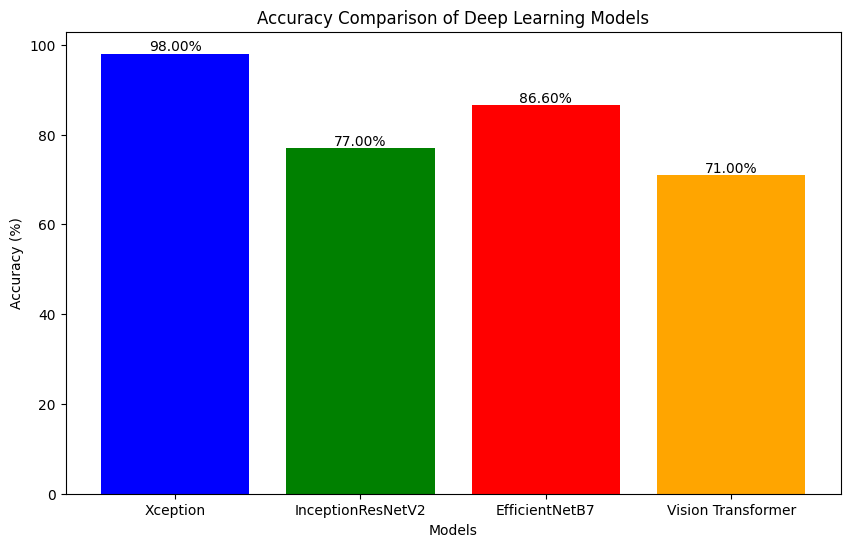

In [19]:

import matplotlib.pyplot as plt


model_names = ["Xception", "InceptionResNetV2", "EfficientNetB7", "Vision Transformer"]
accuracies = [test_acc * 100, inception_test_acc * 100, efficientnet_test_acc * 100, accuracy * 100]
colors = ['blue', 'green', 'red', 'orange']

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=colors)

# Add labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Deep Learning Models")

# Add percentage values on top of the bars
for bar, accuracy in zip(bars, accuracies):
  plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{accuracy:.2f}%", ha='center', va='bottom')

# Show the plot
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

# Extract first frame
frames = extract_frames(video_path, num_frames=1)
if frames is None or len(frames) == 0:
    print("Error: Could not extract frames from video.")
else:
    frames = frames / 255.0  # Normalize
    frames = np.expand_dims(frames[0], axis=0)  # Add batch dimension

    # Predict using the model
    predictions = ensemble_model.predict(frames)
    class_idx = np.argmax(predictions)

    # Display result
    if class_idx == 0:
      print("✅  The video is REAL.")

    else:
      print("❌ The video is FAKE.")



Saving id6_id1_0000.mp4 to id6_id1_0000.mp4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
❌ The video is FAKE.


In [ ]:
import joblib

# Save the model using joblib
joblib.dump(ensemble_model, "deepfake_model.pkl")




['deepfake_model.pkl']

In [ ]:
# Download the model file
from google.colab import files
files.download("deepfake_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

# Load the model
model = joblib.load("deepfake_model.pkl")


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(ensemble_model)
tflite_model = converter.convert()


Saved artifact at '/tmp/tmpmgbqwvmc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_370')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134727725005712: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134727719202704: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134727653584400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134727653584784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134727653585744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134727653584976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134727653581520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134727653586704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134727653586320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134727653587664: TensorSpec(shape=(), dtype=tf.resource, name=

In [ ]:
with open("deepfake_model.tflite", "wb") as f:
    f.write(tflite_model)

In [ ]:
files.download("deepfake_model.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
import numpy as np
import cv2
import os
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog

REAL_PATH = "/content/Real"
FAKE_PATH = "/content/Fake"

def extract_features(video_path, num_frames=5):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    for i in range(num_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * total_frames // num_frames)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        frame = cv2.resize(frame, (64, 64))
        hog_features = hog(frame, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
        frames.append(hog_features)

    cap.release()

    if frames:
        return np.mean(frames, axis=0)  # Average features
    return None

data, labels = [], []
for file in os.listdir(REAL_PATH):
    features = extract_features(os.path.join(REAL_PATH, file))
    if features is not None:
        data.append(features)
        labels.append(0)  # Real

for file in os.listdir(FAKE_PATH):
    features = extract_features(os.path.join(FAKE_PATH, file))
    if features is not None:
        data.append(features)
        labels.append(1)  # Fake

data = np.array(data)
labels = np.array(labels)

scaler = StandardScaler()
data = scaler.fit_transform(data)

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1)
model.fit(X_train, y_train)

with open("model.pkl", "wb") as file:
    pickle.dump((model, scaler), file)

print("✅ Model saved as model.pkl")


✅ Model saved as model.pkl


In [ ]:
import pickle
import tensorflow as tf



In [ ]:
# Load model.pkl
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

In [ ]:

with open("model.pkl", "rb") as f:
    model_data = pickle.load(f)

print(type(model_data))


<class 'tuple'>


In [ ]:
print(type(model_data))

<class 'tuple'>


In [ ]:
model = model_data[0]  # Extract the actual model


In [ ]:
import tensorflow as tf

if hasattr(model, "save"):
    model.save("model.h5")
    print("Model saved as model.h5")
else:
    print("This is not a Keras model.")


This is not a Keras model.


In [ ]:
import pickle

with open("model.pkl", "rb") as f:
    model_data = pickle.load(f)

print(f"Type of model: {type(model_data)}")


Type of model: <class 'tuple'>


In [ ]:
import pickle

with open("model.pkl", "rb") as f:
    model_data = pickle.load(f)

print(f"Tuple Length: {len(model_data)}")
for i, item in enumerate(model_data):
    print(f"Item {i}: Type = {type(item)}")


Tuple Length: 2
Item 0: Type = <class 'xgboost.sklearn.XGBClassifier'>
Item 1: Type = <class 'sklearn.preprocessing._data.StandardScaler'>


In [ ]:
import pickle

# Load the pickle file
with open("model.pkl", "rb") as f:
    model_data = pickle.load(f)

# Extract the XGBoost model and Scaler
xgb_model = model_data[0]  # XGBClassifier
scaler = model_data[1]  # StandardScaler


In [ ]:
import onnxmltools
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Define the correct input shape (use a list with an integer instead of a tuple)
input_shape = [FloatTensorType([None, 10])]  # Replace 10 with the actual feature size

# Convert XGBoost model to ONNX format
onnx_model = convert_sklearn(xgb_model, initial_types=[("input", input_shape)])

# Save the ONNX model
with open("model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Model successfully converted and saved as model.onnx ✅")


TypeError: Unexpected type for variable raw_name='input', type=[FloatTensorType(shape=[None, 10])].